# 01 - Data Cleaning
**Heart Disease (UCI)** — load the raw dataset, inspect it, clean it, and save a tidy version for EDA and modeling.

## ✅ Step 1 Summary — Data Cleaning

**What it does (in order):**
1. Load dataset
2. Rows/columns (920 × 16)
3. Missing values table
4. Duplicates check (0 found)
5. Drop `id`
6. Binary `target` from `num` (>0 → 1)
7. Handle missing — numeric→median, categorical→mode
8. Clean categoricals — `fbs`/`exang`→int, text lowercased/stripped, `ca`→int
9. Before/after summary table
10. Save cleaned data

**Outputs:**
- `data/processed/heart_cleaned.csv` → 920 rows × 15 cols, 0 missing
- Target balance: 509 disease / 411 no-disease (nicely balanced)

**Figures:**
- `figures/missing_values.png` (bar chart)
- `figures/target_distribution.png` (count + %)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_PATH = "../data/raw/heart_disease_uci.csv"
PROCESSED_PATH = "../data/processed/heart_cleaned.csv"
FIG_DIR = "../figures"
os.makedirs("../data/processed", exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load dataset

In [2]:
df = pd.read_csv(RAW_PATH)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Rows and columns

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()
df.info()

Rows: 920
Columns: 16

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


## 3. Missing values

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table.missing_count > 0].sort_values("missing_count", ascending=False)
missing_table

,missing_count,missing_pct
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


### Missing value bar chart

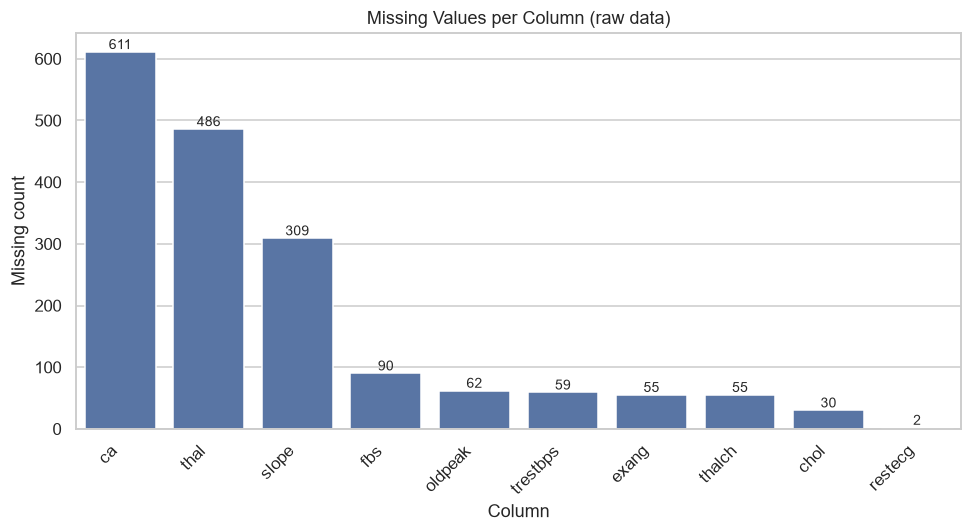

In [5]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=missing_table.index, y=missing_table["missing_count"], color="#4C72B0")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.title("Missing Values per Column (raw data)")
plt.ylabel("Missing count")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/missing_values.png", bbox_inches="tight")
plt.show()

## 4. Duplicates

In [6]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

Duplicate rows: 0


## 5. Drop id column

In [7]:
df = df.drop(columns=["id"])
print("Remaining columns:", list(df.columns))

Remaining columns: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## 6. Create binary target
The original `num` column ranges from 0 (no disease) to 4 (severity). We collapse it into a binary
`target`: **0 = no disease**, **1 = disease present**.

In [8]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## 7. Handle missing values
- **Numeric** columns are imputed with the **median** (robust to outliers).
- **Categorical** columns are imputed with the **mode** (most frequent value).

In [9]:
numeric_cols = ["trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", int(df.isna().sum().sum()))

Remaining missing values: 0


## 8. Clean categorical values
- Convert the boolean-like columns `fbs` and `exang` to integers (0/1).
- Standardize text categories (strip whitespace, lowercase).

In [10]:
df["fbs"] = df["fbs"].astype(bool).astype(int)
df["exang"] = df["exang"].astype(bool).astype(int)

text_cols = ["sex", "dataset", "cp", "restecg", "slope", "thal"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

df["ca"] = df["ca"].astype(int)
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,male,cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0,fixed defect,0
1,67,male,cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3,normal,1
2,67,male,cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2,reversable defect,1
3,37,male,cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0,normal,0
4,41,female,cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0,normal,0


## 9. Before/after cleaning summary

In [11]:
raw = pd.read_csv(RAW_PATH)
summary = pd.DataFrame({
    "metric": ["rows", "columns", "missing_values", "duplicate_rows"],
    "before": [raw.shape[0], raw.shape[1], int(raw.isna().sum().sum()), int(raw.duplicated().sum())],
    "after":  [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
})
summary

,metric,before,after
0,rows,920,920
1,columns,16,15
2,missing_values,1759,0
3,duplicate_rows,0,2


### Target distribution chart

C:\Users\shitu\AppData\Local\Temp\ipykernel_11204\2239563524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=df, order=order, palette=["#55A868", "#C44E52"])
C:\Users\shitu\AppData\Local\Temp\ipykernel_11204\2239563524.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


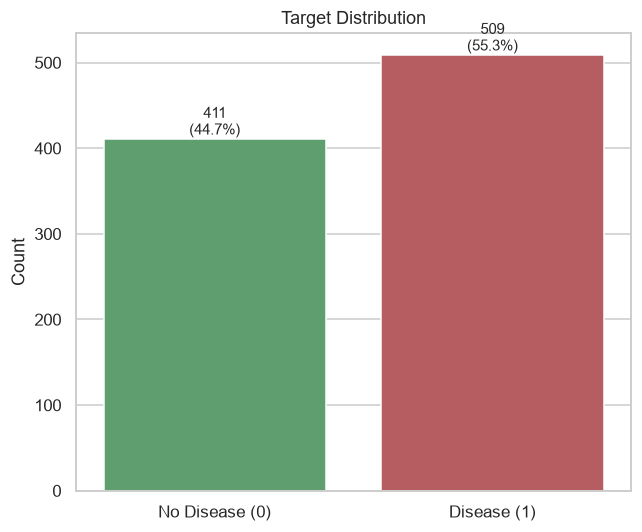

In [12]:
plt.figure(figsize=(6, 5))
order = [0, 1]
ax = sns.countplot(x="target", data=df, order=order, palette=["#55A868", "#C44E52"])
labels = ["No Disease (0)", "Disease (1)"]
ax.set_xticklabels(labels)
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f"{count}\n({count/total*100:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.title("Target Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", bbox_inches="tight")
plt.show()

## 10. Save cleaned data

In [13]:
df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned dataset -> {PROCESSED_PATH}")
print(f"Shape: {df.shape}")
df.head()

Saved cleaned dataset -> ../data/processed/heart_cleaned.csv
Shape: (920, 15)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,male,cleveland,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0,fixed defect,0
1,67,male,cleveland,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3,normal,1
2,67,male,cleveland,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2,reversable defect,1
3,37,male,cleveland,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0,normal,0
4,41,female,cleveland,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0,normal,0
